# CELL 1 (Markdown)

# Template Eksperimen MSML_
## 1. Perkenalan Dataset
Dataset yang digunakan dalam eksperimen ini adalah **Customer Personality Analysis** yang diperoleh dari public repository **Kaggle**. Dataset ini berisi analisis sosiodemografis pelanggan yang digunakan untuk memahami karakteristik, perilaku, dan kebiasaan belanja pelanggan terhadap produk perusahaan.


In [10]:
%pip install seaborn matplotlib jupyter ipywidgets


Note: you may need to restart the kernel to use updated packages.


# CELL 2 (Code)

In [11]:
# 2. Import Library
import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

print("Library berhasil diimpor.")


Library berhasil diimpor.


# CELL 3 (Markdown)

## 3. Memuat Dataset
Pada tahap ini, dataset diunduh secara otomatis dari Kaggle menggunakan pustaka `kagglehub`, kemudian dimuat ke dalam DataFrame Pandas. Karena dataset menggunakan format pemisah Tab (`\t`), parameter `sep='\t'` digunakan agar data terstruktur dengan benar.


# CELL 4 (Code)

In [12]:
# Download dataset dari Kaggle
path = kagglehub.dataset_download("imakash3011/customer-personality-analysis")
print("Path ke file dataset:", path)

# Memuat berkas ke dalam Pandas DataFrame
file_path = os.path.join(path, "marketing_campaign.csv")
df = pd.read_csv(file_path, sep="\t")

# Memeriksa beberapa baris awal dataset
df.head()


Path ke file dataset: C:\Users\INFINIX\.cache\kagglehub\datasets\imakash3011\customer-personality-analysis\versions\1


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


# CELL 5 (Markdown)

## 4. Exploratory Data Analysis (EDA)
Tahap ini bertujuan untuk memahami karakteristik dasar, dimensi data, tipe data tiap kolom, ringkasan statistik, serta mendeteksi adanya nilai kosong (*missing values*), duplikasi, dan pencilan (*outliers*) melalui visualisasi grafik.


# CELL 6 (Code)

In [13]:
# Memeriksa dimensi dan informasi data
print("Dimensi Data:", df.shape)
print("\n--- Informasi Tipe Data ---")
df.info()

print("\n--- Ringkasan Statistik ---")
df.describe()


Dimensi Data: (2240, 29)

--- Informasi Tipe Data ---
<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  


,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


# CELL 7 (Code)

In [14]:
# Memeriksa missing values dan duplikasi
print("Jumlah Missing Values Per Kolom:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nJumlah Data Duplikat:", df.duplicated().sum())


Jumlah Missing Values Per Kolom:
Income    24
dtype: int64

Jumlah Data Duplikat: 0


# CELL 8 (Code)

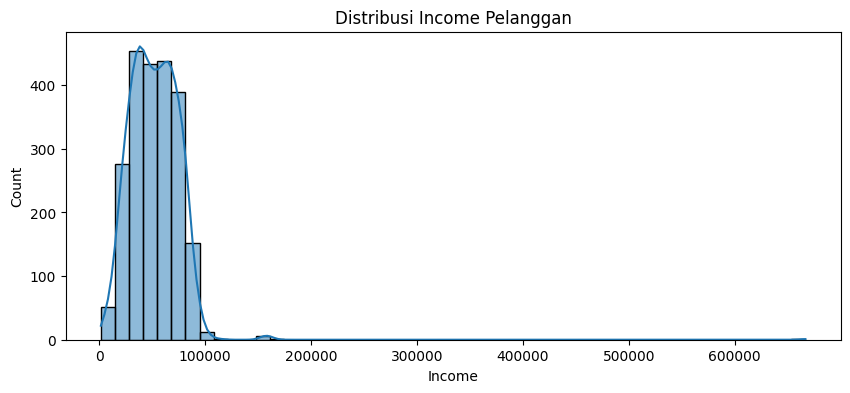

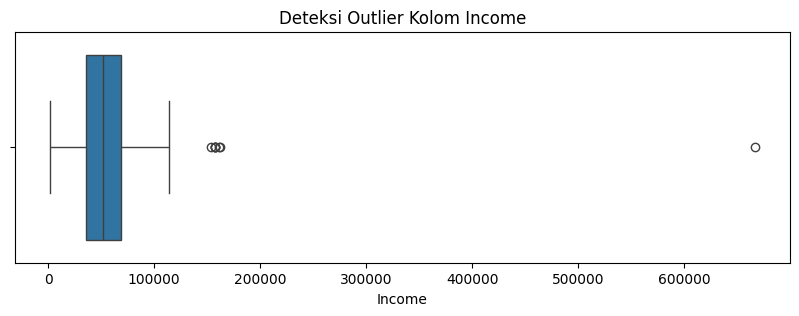

In [15]:
# Visualisasi Distribusi Kolom Income (Pencilan/Outliers awal)
plt.figure(figsize=(10, 4))
sns.histplot(df["Income"], kde=True, bins=50)
plt.title("Distribusi Income Pelanggan")
plt.show()

# Visualisasi Boxplot untuk melihat Outlier secara jelas
plt.figure(figsize=(10, 3))
sns.boxplot(x=df["Income"])
plt.title("Deteksi Outlier Kolom Income")
plt.show()


# CELL 9 (Markdown)

## 5. Data Preprocessing
Pada tahap ini, data dibersihkan dan dipersiapkan agar optimal saat digunakan pada model machine learning. Tahapan meliputi:
1. **Feature Engineering**: Membuat kolom `TotalSpending` dan membuat label `Target` biner (1: *High Value Customer*, 0: *Low Value Customer*) berdasarkan nilai median spending.
2. **Data Cleaning**: Menghapus kolom tidak relevan (`ID`, `Dt_Customer`), mengisi *missing values* dengan median, dan menghapus duplikasi data.
3. **Encoding Data Kategorikal**: Mengubah fitur teks menjadi numerik biner menggunakan `pd.get_dummies()`.
4. **Standardisasi Fitur**: Menyamakan skala nilai fitur numerik menggunakan `StandardScaler`.


# CELL 10 (Code)

In [16]:
# 1. Feature Engineering
spending_cols = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]
df["TotalSpending"] = df[spending_cols].sum(axis=1)

# Membuat target biner berdasarkan median
median_spending = df["TotalSpending"].median()
df["Target"] = (df["TotalSpending"] > median_spending).astype(int)

# 2. Data Cleaning
df.drop(columns=["ID", "Dt_Customer"], errors="ignore", inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)
df.drop_duplicates(inplace=True)

# 3. Encoding Data Kategorikal
df = pd.get_dummies(df, drop_first=True)

# 4. Standardisasi Fitur
scaler = StandardScaler()
features = df.drop(columns=["Target"])
target = df["Target"].reset_index(drop=True)

scaled_features = scaler.fit_transform(features)
X_preprocessed = pd.DataFrame(scaled_features, columns=features.columns)
X_preprocessed["Target"] = target

# Menyimpan hasil preprocessing untuk Kriteria 2
X_preprocessed.to_csv("customer_preprocessed.csv", index=False)
print("✔ Preprocessing Selesai. Data siap digunakan untuk pelatihan model.")
X_preprocessed.head()


✔ Preprocessing Selesai. Data siap digunakan untuk pelatihan model.


,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,Education_Master,Education_PhD,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO,Target
0,-0.984645,0.228270,-0.829097,-0.932051,0.312088,0.984044,1.554193,1.657389,2.464511,1.458453,...,-0.445648,-0.529009,-0.038208,-0.342438,-0.793381,1.895719,-0.582213,-0.18903,-0.031189,1
1,-1.235251,-0.236579,1.031625,0.898255,-0.377754,-0.870634,-0.634978,-0.708461,-0.646539,-0.627684,...,-0.445648,-0.529009,-0.038208,-0.342438,-0.793381,1.895719,-0.582213,-0.18903,-0.031189,0
2,-0.316363,0.759375,-0.829097,-0.932051,-0.791659,0.362846,0.572841,-0.178335,1.348193,-0.148113,...,-0.445648,-0.529009,-0.038208,-0.342438,-0.793381,-0.527504,1.717584,-0.18903,-0.031189,1
3,1.270808,-1.012958,1.031625,-0.932051,-0.791659,-0.870634,-0.559489,-0.647124,-0.500137,-0.579727,...,-0.445648,-0.529009,-0.038208,-0.342438,-0.793381,-0.527504,1.717584,-0.18903,-0.031189,0
4,1.020202,0.234379,1.031625,-0.932051,1.553804,-0.389131,0.421863,-0.217766,0.158674,-0.004241,...,-0.445648,1.890326,-0.038208,-0.342438,1.260428,-0.527504,-0.582213,-0.18903,-0.031189,1
